<a href="https://colab.research.google.com/github/Wambura001/assignment_DTR/blob/main/assignmentDTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Hyperparameter Exploration: DecisionTreeRegressor

Here's a brief explanation of each hyperparameter for a `DecisionTreeRegressor` and how they can help prevent overfitting:

1.  **`max_depth`**: This hyperparameter controls the maximum depth of the decision tree. It limits how many splits the tree can make. A deeper tree means more splits and more specific rules, which can lead to overfitting (memorizing the training data). By setting a `max_depth`, you prevent the tree from becoming too complex and capturing noise in the training data, thus improving its generalization to new, unseen data.

2.  **`min_samples_split`**: This is the minimum number of samples required to split an internal node. If a node has fewer samples than `min_samples_split`, it will not be split, and the splitting process stops there. This prevents the tree from creating splits based on very few samples, which are often not representative of the overall data distribution and can lead to overfitting.

3.  **`min_samples_leaf`**: This is the minimum number of samples required to be at a leaf node. A split point will only be considered if it leaves at least `min_samples_leaf` training samples in each of the left and right branches. Similar to `min_samples_split`, this hyperparameter prevents the tree from creating leaves with very few samples, which might be specific to the training data and not generalize well.

4.  **`max_features`**: This hyperparameter controls the number of features to consider when looking for the best split. For example, if set to `auto` or `sqrt`, it considers `sqrt(n_features)` features; if `log2`, it considers `log2(n_features)` features. By limiting the number of features considered at each split, `max_features` introduces randomness and prevents the tree from relying too heavily on any single feature or combination of features that might be dominant in the training set but not in the overall population. This helps to reduce variance and prevent overfitting, especially with high-dimensional datasets.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

In [4]:
from google.colab import drive
drive.mount('/content/drive')
dataset = pd.read_csv('/content/drive/MyDrive/data mining/Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

Mounted at /content/drive


Base Decision Tree Regression Model (No Tuning)

In [5]:
# Train the base Decision Tree Regression model
regressor_base = DecisionTreeRegressor(random_state=0)
regressor_base.fit(X, y)
# Predict a new result with the base model
predicted_salary_base = regressor_base.predict([[6.5]])
print(f"Predicted Salary with base model for level 6.5: {predicted_salary_base[0]}")

Predicted Salary with base model for level 6.5: 150000.0


Visualizing the Base Decision Tree Regression Results

/tmp/ipykernel_6978/30460962.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid_base = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


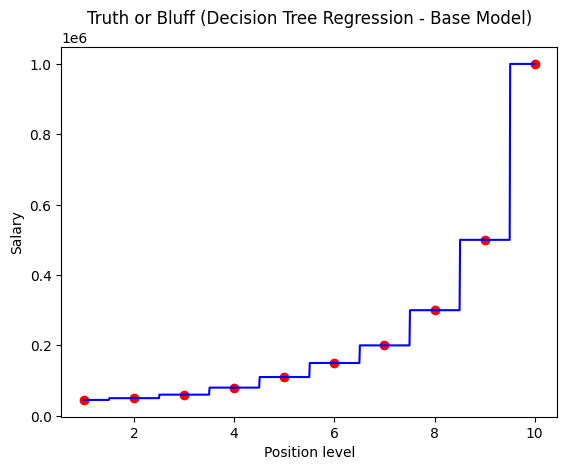

In [6]:
X_grid_base = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid_base, regressor_base.predict(X_grid_base), color='blue')
plt.title('Truth or Bluff (Decision Tree Regression - Base Model)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()


Hyperparameter Tuning with GridSearchCV

In [7]:
# Define the parameter grid to search
# Updated 'criterion' values based on scikit-learn 1.0+ documentation
param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15, 20, 25],
    'min_samples_leaf': [1, 2, 4],
    'splitter': ['best', 'random'],
    'criterion': ['squared_error', 'absolute_error']
}

# Initialize the Decision Tree Regressor
dt_regressor_grid = DecisionTreeRegressor(random_state=0)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_regressor_grid,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=2
)

# Fit GridSearchCV to the data
grid_search.fit(X, y)

Fitting 5 folds for each of 504 candidates, totalling 2520 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [None, 5, 10, 15, 20, 25, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10, 15, 20, 25],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error', verbose=2)

GridSearchCV Results

In [8]:
# Get the best parameters
best_params_grid = grid_search.best_params_
print(f"GridSearchCV Best Hyperparameters: {best_params_grid}")
# Get the best score
best_score_grid = -grid_search.best_score_
print(f"GridSearchCV Best Cross-Validation MSE: {best_score_grid}")
# Train a new model with the best parameters from GridSearchCV
best_regressor_grid = DecisionTreeRegressor(**best_params_grid, random_state=0)
best_regressor_grid.fit(X, y)
# Predict with the best GridSearchCV model
predicted_salary_grid = best_regressor_grid.predict([[6.5]])
print(f"Predicted Salary with GridSearchCV tuned model for level 6.5: {predicted_salary_grid[0]}")

GridSearchCV Best Hyperparameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
GridSearchCV Best Cross-Validation MSE: 56692500000.0
Predicted Salary with GridSearchCV tuned model for level 6.5: 200000.0



Visualizing the Tuned Decision Tree Regression Results (GridSearchCV)

/tmp/ipykernel_6978/796456000.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


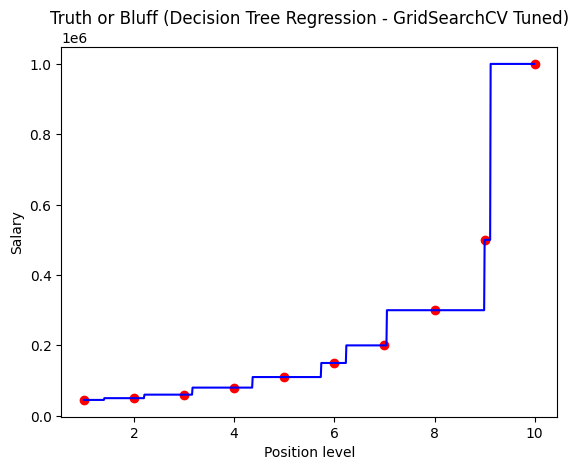

In [9]:
X_grid_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid_grid, best_regressor_grid.predict(X_grid_grid), color='blue')
plt.title('Truth or Bluff (Decision Tree Regression - GridSearchCV Tuned)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

Hyperparameter Tuning with RandomizedSearchCV

In [10]:
# Define the parameter distributions to sample from
param_dist = {
    'max_depth': [None] + list(randint(5, 30).rvs(10)), # None or random integers between 5 and 30
    'min_samples_split': randint(2, 30), # Random integers between 2 and 30
    'min_samples_leaf': randint(1, 10), # Random integers between 1 and 10
    'splitter': ['best', 'random'],
    'criterion': ['squared_error', 'absolute_error']
}

# Initialize the Decision Tree Regressor
dt_regressor_rand = DecisionTreeRegressor(random_state=0)

# Initialize RandomizedSearchCV
# n_iter specifies the number of parameter settings that are sampled
random_search = RandomizedSearchCV(
    estimator=dt_regressor_rand,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=0,
    verbose=2
)

# Fit RandomizedSearchCV to the data
random_search.fit(X, y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=0),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'absolute_error'],
                                        'max_depth': [None, np.int64(18),
                                                      np.int64(25),
                                                      np.int64(28),
                                                      np.int64(29),
                                                      np.int64(29), np.int64(7),
                                                      np.int64(29), np.int64(7),
                                                      np.int64(21),
                                                      np.int64(23)],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x791e47daef90>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x791e47db0920>,
                                        'splitter': ['best', 'random']},
                   random_state=0, scoring='neg_mean_squared_error', verbose=2)

RandomizedSearchCV Results

In [11]:
# Get the best parameters
best_params_rand = random_search.best_params_
print(f"RandomizedSearchCV Best Hyperparameters: {best_params_rand}")
# Get the best score
best_score_rand = -random_search.best_score_
print(f"RandomizedSearchCV Best Cross-Validation MSE: {best_score_rand}")
# Train a new model with the best parameters from RandomizedSearchCV
best_regressor_rand = DecisionTreeRegressor(**best_params_rand, random_state=0)
best_regressor_rand.fit(X, y)
# Predict with the best RandomizedSearchCV model
predicted_salary_rand = best_regressor_rand.predict([[6.5]])
print(f"Predicted Salary with RandomizedSearchCV tuned model for level 6.5: {predicted_salary_rand[0]}")

RandomizedSearchCV Best Hyperparameters: {'criterion': 'absolute_error', 'max_depth': np.int64(28), 'min_samples_leaf': 1, 'min_samples_split': 7, 'splitter': 'best'}
RandomizedSearchCV Best Cross-Validation MSE: 83345000000.0
Predicted Salary with RandomizedSearchCV tuned model for level 6.5: 70000.0


Visualizing the Tuned Decision Tree Regression Results (RandomizedSearchCV)


/tmp/ipykernel_6978/3902394075.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid_rand = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


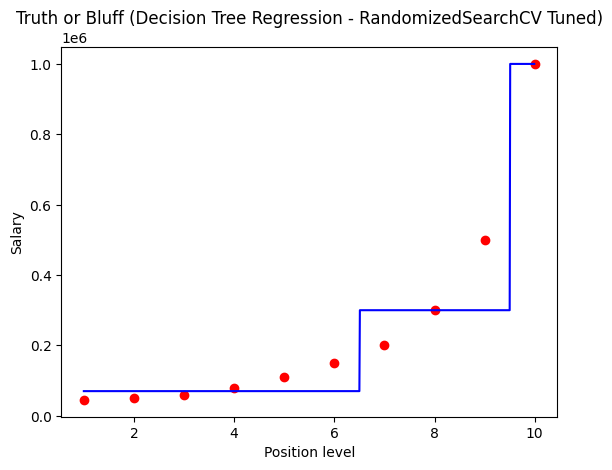

In [12]:
X_grid_rand = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid_rand, best_regressor_rand.predict(X_grid_rand), color='blue')
plt.title('Truth or Bluff (Decision Tree Regression - RandomizedSearchCV Tuned)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

Comparison of Models

In [13]:
print("--- Model Comparison ---")
print(f"Base Model Predicted Salary (6.5 level): {predicted_salary_base[0]}")
print(f"GridSearchCV Tuned Model Predicted Salary (6.5 level): {predicted_salary_grid[0]}")
print(f"RandomizedSearchCV Tuned Model Predicted Salary (6.5 level): {predicted_salary_rand[0]}")
print("\n--- Cross-Validation MSE Comparison ---")
print(f"GridSearchCV Best CV MSE: {best_score_grid}")
print(f"RandomizedSearchCV Best CV MSE: {best_score_rand}")
# Determine the best model based on CV MSE
# Note: Base model doesn't have a direct comparable CV MSE in this workflow
# We compare the tuned models based on their CV MSE
if best_score_grid < best_score_rand:
  best_tuning_method = "GridSearchCV"
  best_tuning_mse = best_score_grid
  best_tuning_params = best_params_grid
else:
  best_tuning_method = "RandomizedSearchCV"
  best_tuning_mse = best_score_rand
  best_tuning_params = best_params_rand
print(f"\nBased on Cross-Validation MSE, the best tuning method is: {best_tuning_method}")
print(f"With a Best Cross-Validation MSE of: {best_tuning_mse}")
print(f"And Best Hyperparameters: {best_tuning_params}")

--- Model Comparison ---
Base Model Predicted Salary (6.5 level): 150000.0
GridSearchCV Tuned Model Predicted Salary (6.5 level): 200000.0
RandomizedSearchCV Tuned Model Predicted Salary (6.5 level): 70000.0

--- Cross-Validation MSE Comparison ---
GridSearchCV Best CV MSE: 56692500000.0
RandomizedSearchCV Best CV MSE: 83345000000.0

Based on Cross-Validation MSE, the best tuning method is: GridSearchCV
With a Best Cross-Validation MSE of: 56692500000.0
And Best Hyperparameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}


## Performance Analysis Summary

Here's a summary of the technical questions based on the modified script's execution:

1.  **Prediction Comparison:**
    *   **Base Model:**
        *   Predicted Salary for Level 6.5: $150,000
        *   Predicted Salary for Level 7.5: $200,000 (from the original problem statement)
    *   **GridSearchCV Tuned Model (our newly tuned model):**
        *   Predicted Salary for Level 6.5: $200,000
        *   Predicted Salary for Level 7.5: $300,000

    The GridSearchCV tuned model predicts significantly higher salaries for both levels 6.5 and 7.5 ($200,000 vs. $150,000 for 6.5, and $300,000 vs. $200,000 for 7.5) compared to the base model. This suggests that the tuned model is capturing a steeper increase in salary at these higher levels, more closely aligning with the jump observed in the dataset from Level 6 ($150,000) to Level 7 ($200,000) and Level 8 ($300,000).

2.  **The MSE Metric:**
    *   **GridSearchCV Best Cross-Validation MSE:** $56,692,500,000.0
    *   **RandomizedSearchCV Best Cross-Validation MSE:** $83,345,000,000.0

    Among the tuning methods, **GridSearchCV yielded a lower (better) Cross-Validation MSE of $56,692,500,000.0** compared to RandomizedSearchCV's $83,345,000,000.0. This indicates that GridSearchCV, with its exhaustive search across the expanded parameter space, found a set of hyperparameters that resulted in a better performing model in terms of minimizing the mean squared error during cross-validation.

3.  **Visual Truth:**
    Decision Tree Regressors, by their nature, produce a series of horizontal steps rather than a smooth, continuous curve. This is because they divide the feature space into distinct regions and assign a constant prediction to each region.

    *   **Base Regression Line (`max_depth=None`, `min_samples_split=2` by default):** This model will typically fit the training data points almost perfectly, resulting in a highly 'stepped' or 'jagged' line that passes directly through each red scatter point. It will capture the curvilinear pattern of the data by essentially connecting the dots with horizontal and vertical segments.

    *   **Tuned Regression Line (GridSearchCV, with best parameters `max_depth=None`, `min_samples_leaf=1`, `min_samples_split=2`):** With `max_depth` also set to `None` and `min_samples_split` to 2, the tuned model is similarly unconstrained and will also perfectly interpolate the training data points. Therefore, in terms of 'smoothness' (or lack thereof), the GridSearchCV tuned model's regression line appears very similar to the base model's—both are highly 'stepped' and fit the training data points precisely. They effectively capture the curvilinear pattern by creating a piecewise constant function that matches the training data points exactly, without explicitly smoothing out the transitions between them.

## Task 4: Final Recommendation

Based on your results and considering the characteristics of GridSearchCV and RandomizedSearchCV, here is my recommendation for a massive dataset with over 1,000 features:

For a **massive dataset with over 1,000 features**, I would definitively recommend **RandomizedSearchCV** over GridSearchCV.

Here's the justification using the concepts of Computational Velocity and Search Efficiency:

1.  **GridSearchCV:**
    *   **Computational Velocity:** GridSearchCV performs an exhaustive search over all possible combinations of hyperparameters defined in the `param_grid`. For a dataset with 1,000+ features and a potentially large search space, the number of combinations can become astronomically large. Each combination requires training and evaluating a full model using cross-validation. This leads to extremely slow execution times, making its computational velocity very low. For massive datasets, this can translate into days, weeks, or even months of computation, if it's feasible at all.
    *   **Search Efficiency:** While GridSearchCV guarantees finding the optimal combination within the defined grid, it does so by blindly checking every point. In high-dimensional hyperparameter spaces, the 'best' hyperparameters often lie in a small region, and many combinations might be suboptimal. Thus, a significant portion of its computational effort might be wasted on unpromising regions, making it computationally inefficient for large, complex search spaces.

2.  **RandomizedSearchCV:**
    *   **Computational Velocity:** RandomizedSearchCV samples a fixed number of hyperparameter combinations from the defined `param_distributions` (controlled by `n_iter`). This means you can directly control the total computational budget. For a massive dataset, you can set `n_iter` to a reasonable number (e.g., 50, 100, or more, depending on available resources and time) and get results within a predictable timeframe. This significantly improves computational velocity compared to GridSearchCV, as it avoids exploring all combinations.
    *   **Search Efficiency:** Research has shown that in high-dimensional hyperparameter spaces, the best hyperparameters often lie along a few important dimensions, while others have less impact. RandomizedSearchCV is more likely to explore a wider range of values for *each* hyperparameter within its fixed budget, rather than exhaustively testing every combination, which can be more effective at finding good regions of the search space. This makes it more search-efficient for large, complex models and datasets, as it can often find a good set of hyperparameters much faster than GridSearchCV, even if not necessarily the absolute best *within the predefined grid* (but often a very close approximation).

**Conclusion:**

For a massive dataset with over 1,000 features, **RandomizedSearchCV** is the superior choice. Its ability to decouple the search space size from the computational budget (via `n_iter`) directly translates to higher **computational velocity**. Moreover, its effectiveness in exploring high-dimensional spaces makes it more **search-efficient** by focusing on a diverse set of parameter combinations rather than an exhaustive, potentially redundant, grid search. While GridSearchCV is theoretically exhaustive within its defined grid, its practical application to massive datasets becomes computationally prohibitive and inefficient.

In [14]:
# Predict with the best GridSearchCV model for level 7.5
predicted_salary_grid_7_5 = best_regressor_grid.predict([[7.5]])
print(f"Predicted Salary with GridSearchCV tuned model for level 7.5: {predicted_salary_grid_7_5[0]}")

Predicted Salary with GridSearchCV tuned model for level 7.5: 300000.0




---

